In [42]:
import numpy as np
import matplotlib.pyplot as plt
from plant.parameters import params
import sys, os
sys.path.append(os.path.abspath('..'))
from plant.battery import Uoc, coef_cubic,battery_step, thermal_model
from plant.powertrain import powertrain
from scipy.interpolate import RegularGridInterpolator

## 1. Formulate optimization problem (multi lap)

**Objective**

$$
\min \quad J = \sum_{k=0}^{N-1} \dot{m}(k)\, \Delta t,
\qquad
\dot{m}(k) = \frac{P_{ICE}(k) + P_{ICE,0}}{\eta_{ICE}\, H_{lhv}}
$$

Here $N$ is the number of samples over the whole race (all laps), not a single lap. Let $\ell(k)$ denote the lap index of sample $k$.

**State dynamics**

$$
SoC(k+1) = SoC(k) - \frac{\Delta t}{Q_{bat} V_{oc}(SoC(k))}\, P_{MGU\text{-}K}(k)
$$

$$
E_{ES2K}(k+1) =
\begin{cases}
0, & \ell(k+1) > \ell(k) \quad \text{(new lap)} \\[4pt]
E_{ES2K}(k) + \max\big(P_{MGU\text{-}K}(k), 0\big)\, \Delta t, & \text{otherwise}
\end{cases}
$$

**Power balance**

$$
P_{gb}(k) =
\begin{cases}
P_{ICE}(k) + P_{MGU\text{-}K}(k), & P_{gb}(k) \ge 0 \\[4pt]
P_{MGU\text{-}K}(k) + P_{brake}(k), & P_{gb}(k) < 0
\end{cases}
$$

**Control bounds**

$$
\begin{cases}
P_{gb}(k) - P_{ICE}^{max} \le P_{MGU\text{-}K}(k) \le P_{gb}(k), & P_{gb}(k) \ge 0 \\[6pt]
P_{gb}(k) \le P_{MGU\text{-}K}(k) \le 0, & P_{gb}(k) < 0
\end{cases}
$$

together with, at every $k$:

$$
P_{MGU\text{-}K}^{min} \le P_{MGU\text{-}K}(k) \le P_{MGU\text{-}K}^{max}
$$

$$
\frac{(SoC^{max} - SoC(k))\,Q_{bat}V_{oc}}{-\Delta t} \le P_{MGU\text{-}K}(k) \le \frac{(SoC^{min} - SoC(k))\,Q_{bat}V_{oc}}{-\Delta t}
$$

$$
P_{MGU\text{-}K}(k) \le \frac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t}
$$

**Component and regulatory limits**

$$
0 \le P_{ICE}(k) \le P_{ICE}^{max}
$$

$$
P_{brake}(k) \le 0
$$

$$
0 \le \dot{m}(k) \le \dot{m}^{max} = 75 \text{ kg/h}
$$

$$
0 \le E_{ES2K}(k) \le E_{ES2K}^{max} = 9 \text{ MJ}
$$

**Terminal condition**

$$
V(SoC, E_{ES2K}, N) = 0
$$

applied once, at the end of the race, not at the end of each lap.

In [ ]:
#Define Parameters
dt = 0.1

Q_bat = params['E_pack_capacity']/params['V_oc_nom'] 

# Limits on Batt Power, Eng Power, SOC
P_MGU_K_min = params['P_MGU_min']   # -200[kW]
P_MGU_K_max = params['P_MGU_max']   # 350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SoC_min = params['SoC_min']     # 0.2[-]
SoC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']     # 0.489
P_ICE0 = params['P_ICE0']       # 15[kW]
LHV = params['LHV']

#data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')
data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')

t = data[0,:]
N_lap = data[1,:] - 3 #the 3 laps starts from lap 3 to lap 7
v = data[2,:]
a = data[3,:]

power_data = np.load('data/multi_lap_Canada/power_domand_multilap.npy')

Pgb = power_data[1,:]


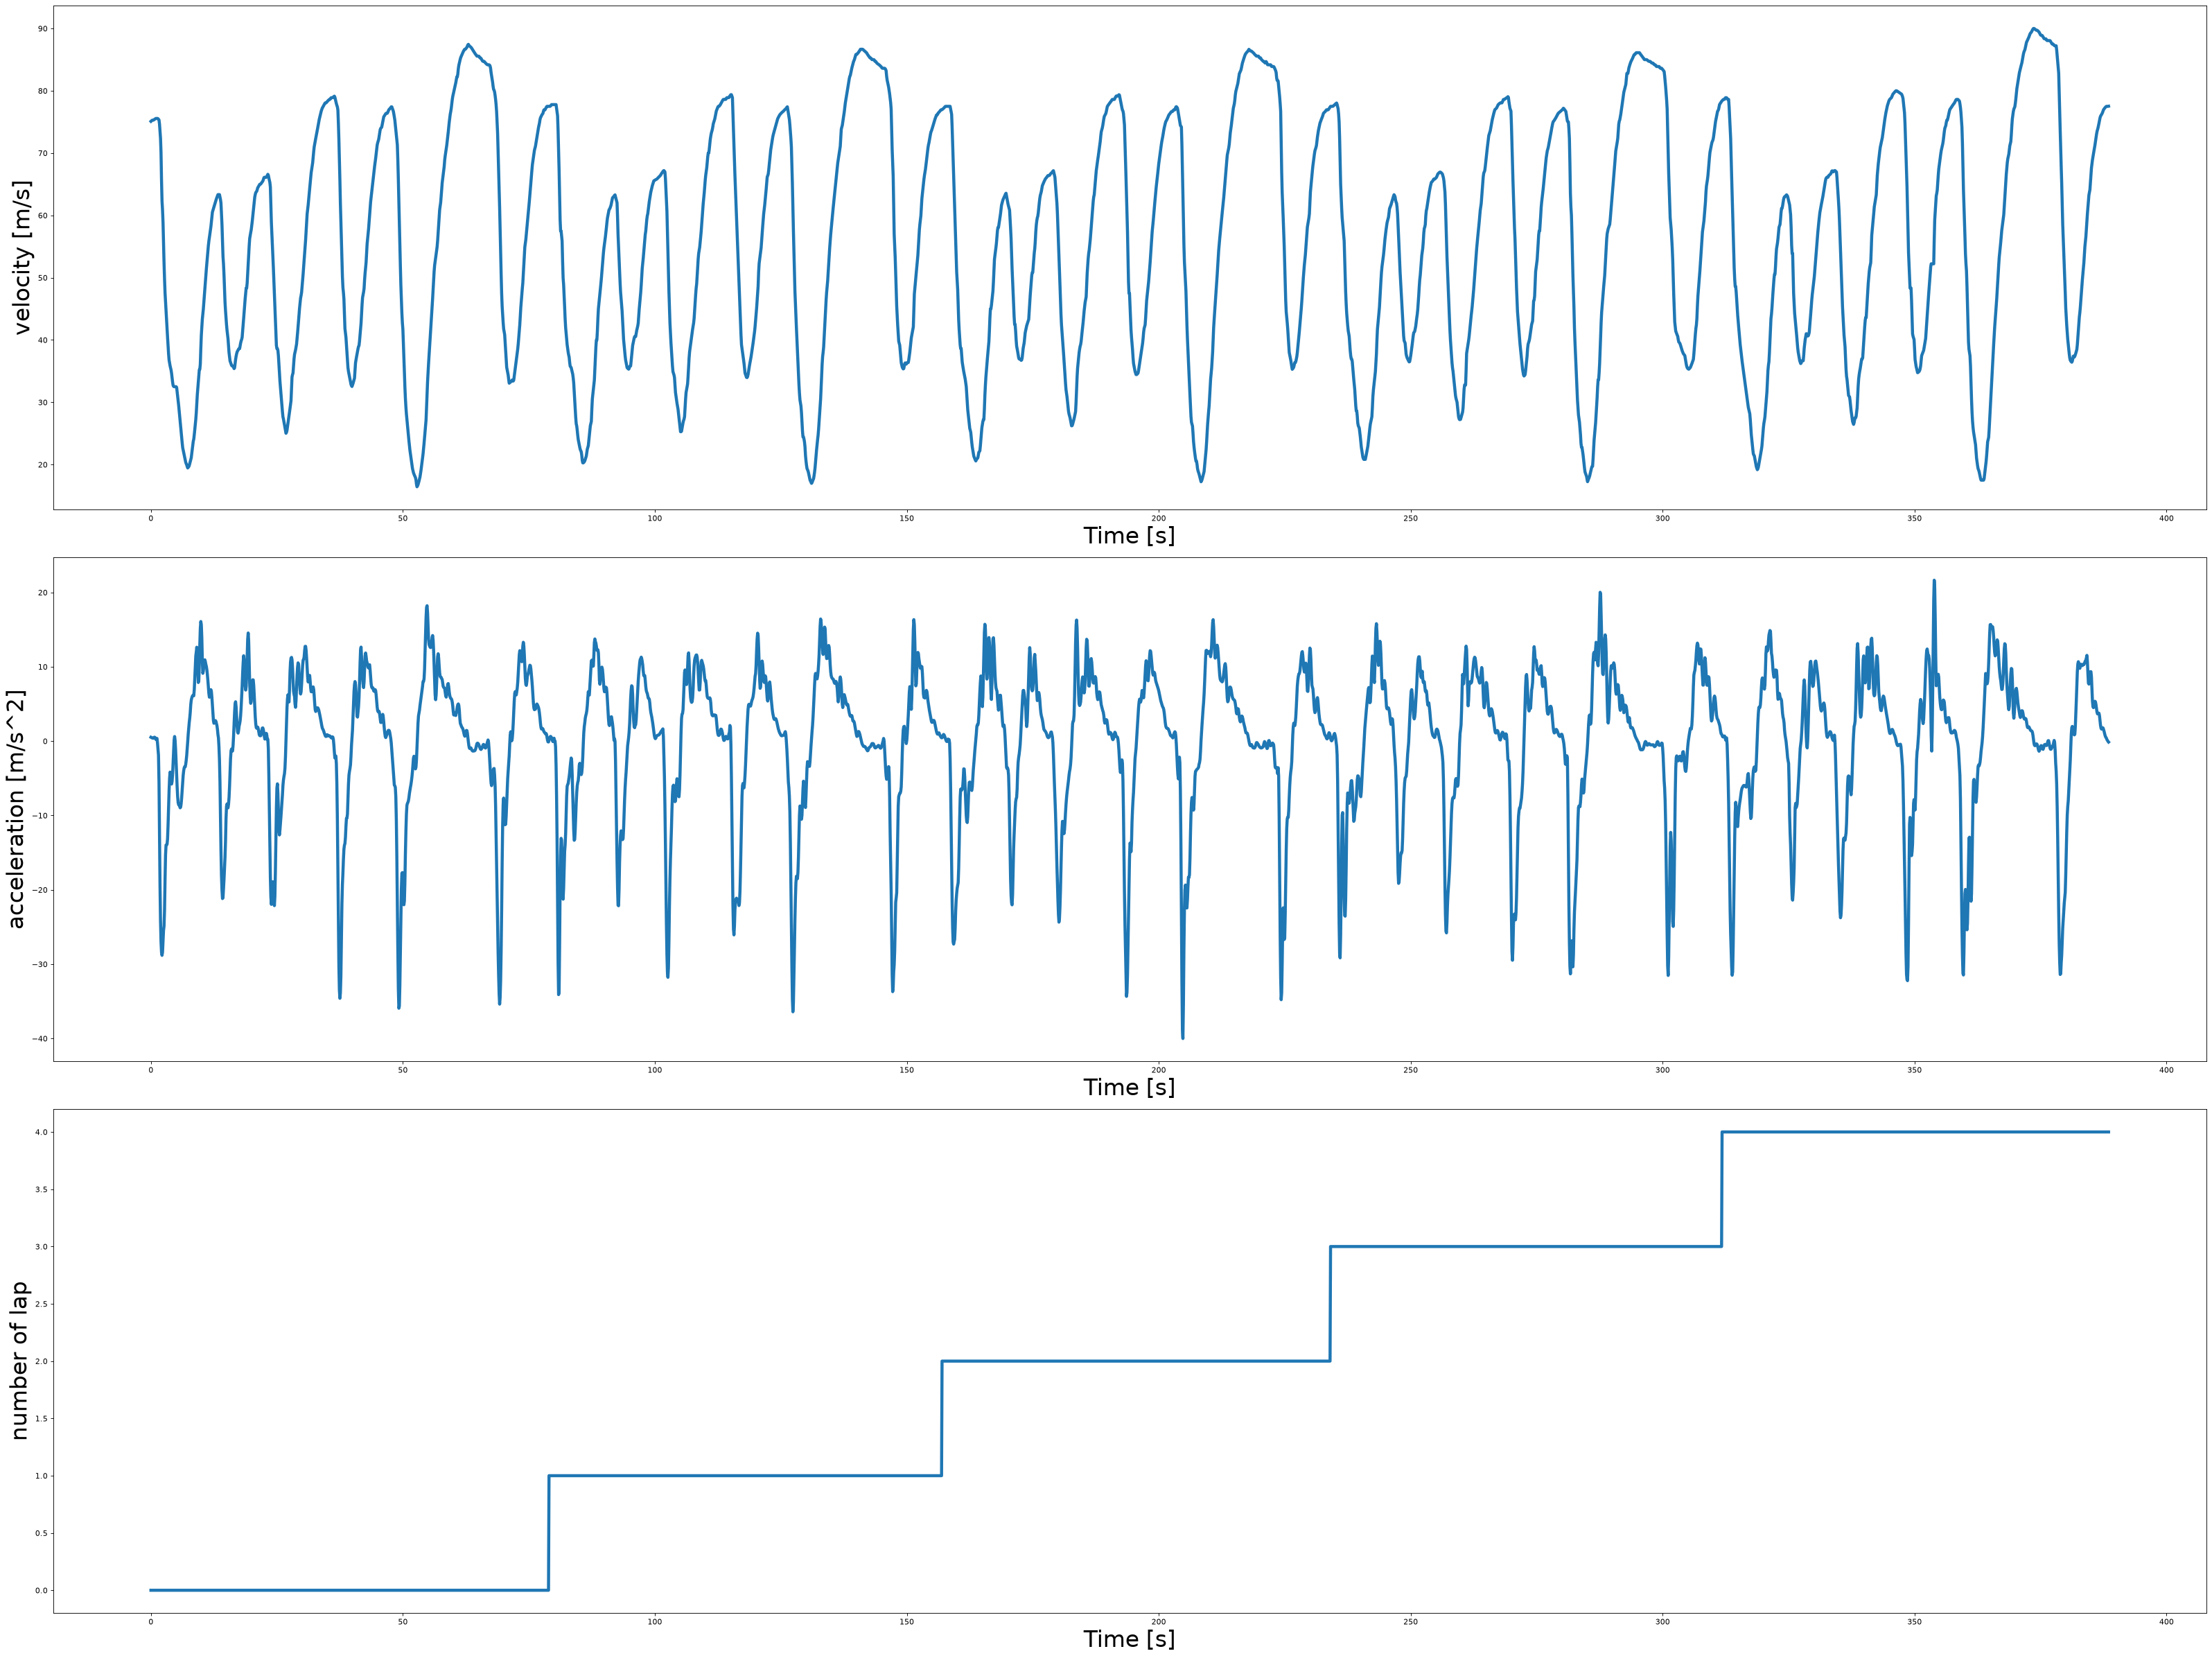

In [44]:
plt.figure(num=1, figsize=(40, 30), dpi=80, facecolor='w', edgecolor='k')

plt.subplot(3,1,1)
plt.plot(t,v, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('velocity [m/s]', fontsize=30)

plt.subplot(3,1,2)
plt.plot(t,a, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('acceleration [m/s^2]', fontsize=30)

plt.subplot(3,1,3)
plt.plot(t,N_lap, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('number of lap', fontsize=30)
plt.tight_layout()
plt.show()

In [45]:
SoC_grid = np.linspace(SoC_min,SoC_max, 50)
E_ES2K_grid = np.linspace(0,E_ES2K_max, 50)

#grid size
ns = len(SoC_grid)
ne = len(E_ES2K_grid)

#planning horizon (time steps)
N = len(t)
nu = 200

SoC_mesh,E_ES2K_mesh  = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')
SoC_max_term = (SoC_max-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt
SoC_min_term = (SoC_min-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt

E_ES2K_term = (E_ES2K_max-E_ES2K_mesh)/dt

beta = 0.1
SoC_target = 0.7

## 2. Backward pass

I now solve the DP backward in time over the whole race, from the last sample to the first. At each step k I build the feasible range for P_MGU-K(k) from the bounds above, evaluate the fuel cost for every candidate control, and combine it with the interpolated value function at k+1. The state that resets is E_ES2K, which must go back to zero at the start of every lap, since the deploy budget is a per lap quantity and cannot carry over. The terminal condition is applied only once, at the very last sample of the race.

In [ ]:
def backward_step(SoC_target=None, beta=0.0):
    # Preallocate Value Function (rows index state, columns index time)
    V = np.inf*np.ones((ns,ne,N+1))
    #preollacate control (row index states, and columns index time)
    u_star = np.zeros_like(V)
    # Boundary Condition of Value Function (Principle of Optimality)
    V[:,:,N] = 0
    for k in range(N-1, -1, -1):
        interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)
        if Pgb[k]>=0:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_K_min, Pgb[k] - P_eng_max))
            ub = np.minimum(SoC_min_term,E_ES2K_term)
            ub = np.minimum(ub, np.minimum(P_MGU_K_max,Pgb[k]))

        else:
            lb = np.maximum(Pgb[k],np.maximum(SoC_max_term,P_MGU_K_min))
            ub = np.minimum(0,SoC_min_term)

        P_mgu_k_mesh = np.linspace(lb,ub,nu, axis=-1)

        if Pgb[k]>=0:
            P_eng = Pgb[k]-P_mgu_k_mesh
        else:
            P_eng = np.zeros_like(P_mgu_k_mesh)

        mdot = (P_eng+P_ICE0)/(eta_ICE*LHV)
        mdot = np.clip(mdot, 0,params['m_dot_max']/3600)

        # cost-per-time
        g_k = mdot*dt

        #compute the dynamics of the states
        Soc_next = SoC_mesh[:,:,np.newaxis] - dt*P_mgu_k_mesh/(Q_bat*Uoc(SoC_mesh[:,:,np.newaxis],coef_cubic))
        if k< N-1 and N_lap[k] < N_lap[k+1]:
            E_ES2K_next = np.zeros_like(Soc_next)
        else:
            E_ES2K_next = E_ES2K_mesh[:,:,np.newaxis] + np.maximum(0, P_mgu_k_mesh)*dt

        point = np.stack([Soc_next.ravel(), E_ES2K_next.ravel()], axis=-1)
        V_next = interp_Vnext(point).reshape(ns,ne,nu)
        
        V[:,:,k] = np.min(g_k+V_next, axis =-1) 
        ind = np.argmin(g_k+V_next, axis = -1)
        u_star[:,:,k] = np.take_along_axis(P_mgu_k_mesh, ind[:,:,np.newaxis], axis=-1).squeeze(axis=-1)

        if SoC_target is not None and k > 0 and N_lap[k-1] < N_lap[k]:
            lap_idx = int(N_lap[k])
            if np.isscalar(SoC_target):
                target = SoC_target  
            else:
                target=SoC_target[lap_idx]
            V[:,:,k] += beta * np.maximum(0, target - SoC_mesh)**2

    return V, u_star




## 3. Simulate optimal energy management results

Now that I've solved the DP over the full race, I can use the `u_star` map to simulate the optimal strategy lap by lap. I run the forward pass for five different initial battery charges to see how the starting SoC affects total fuel consumption and the SoC trajectory across the five laps.

In [47]:
V_baseline, u_star_baseline = backward_step(SoC_target=None, beta=0.0)

In [48]:
def foward_step(u, SoC_0, E_ES2K_0):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    E_K2ES_sim = np.zeros(N)
    J_sim = np.zeros(N)
    P_eng_sim= np.zeros(N)
    P_mgu_k_sim =np.zeros(N)
    P_mech_MGU_K_real =np.zeros(N)
    m_dot_sim= np.zeros(N)
    Tbat_sim = np.zeros(N)



    SoC_sim[0] = SoC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_K2ES_sim[0] = 0
    Tbat_sim[0] = params['T_bat_init']

    for k in range(0,(N-1)):
        interp_u = RegularGridInterpolator((SoC_grid,E_ES2K_grid),u[:,:,k], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[k], E_ES2K_sim[k]]])
        P_mgu_k_sim[k] = interp_u(point)[0]

        P_eng_sim[k], P_elect_MGU_K,P_mech_MGU_K_real[k],_, E_ES2K_sim[k+1],E_K2ES_sim[k+1],m_dot_sim[k] = powertrain(Pgb[k],P_mgu_k_sim[k],E_ES2K_sim[k],E_K2ES_sim[k],params,dt, control_mode='P2')
        if N_lap[k+1] > N_lap[k]:
            E_ES2K_sim[k+1] = 0.0
            E_K2ES_sim[k+1] = 0.0
  
        SoC_sim[k+1], _,I2 = battery_step(SoC_sim[k],P_elect_MGU_K, coef_cubic, Tbat_sim[k],params,dt)
        Tbat_sim[k+1] = thermal_model(I2, Tbat_sim[k], params, dt)

        J_sim[k] = m_dot_sim[k]*dt


    return P_eng_sim,P_mech_MGU_K_real, E_ES2K_sim, E_K2ES_sim, SoC_sim,J_sim
print(np.abs(u_star_baseline).max())
SoC_init = 0.9
E_ES2K_init = 0.0
P_eng_sim90,P_mech_MGU_K_real90, E_ES2K_sim90, E_K2ES_sim, SoC_sim90,J_sim90 = foward_step(u_star_baseline,SoC_init,E_ES2K_init)    

fuel_dp = np.sum(J_sim90) * 1e3  # g



print(f"Total fuel: {fuel_dp:.2f} g | final SoC: {SoC_sim90[-2]:.4f} | deploy: {E_ES2K_sim90[-2]/1e6:.3f} MJ")


350000.0
Total fuel: 3578.89 g | final SoC: 0.2000 | deploy: 3.256 MJ


## 4. Result analysis: tracking and shortfall

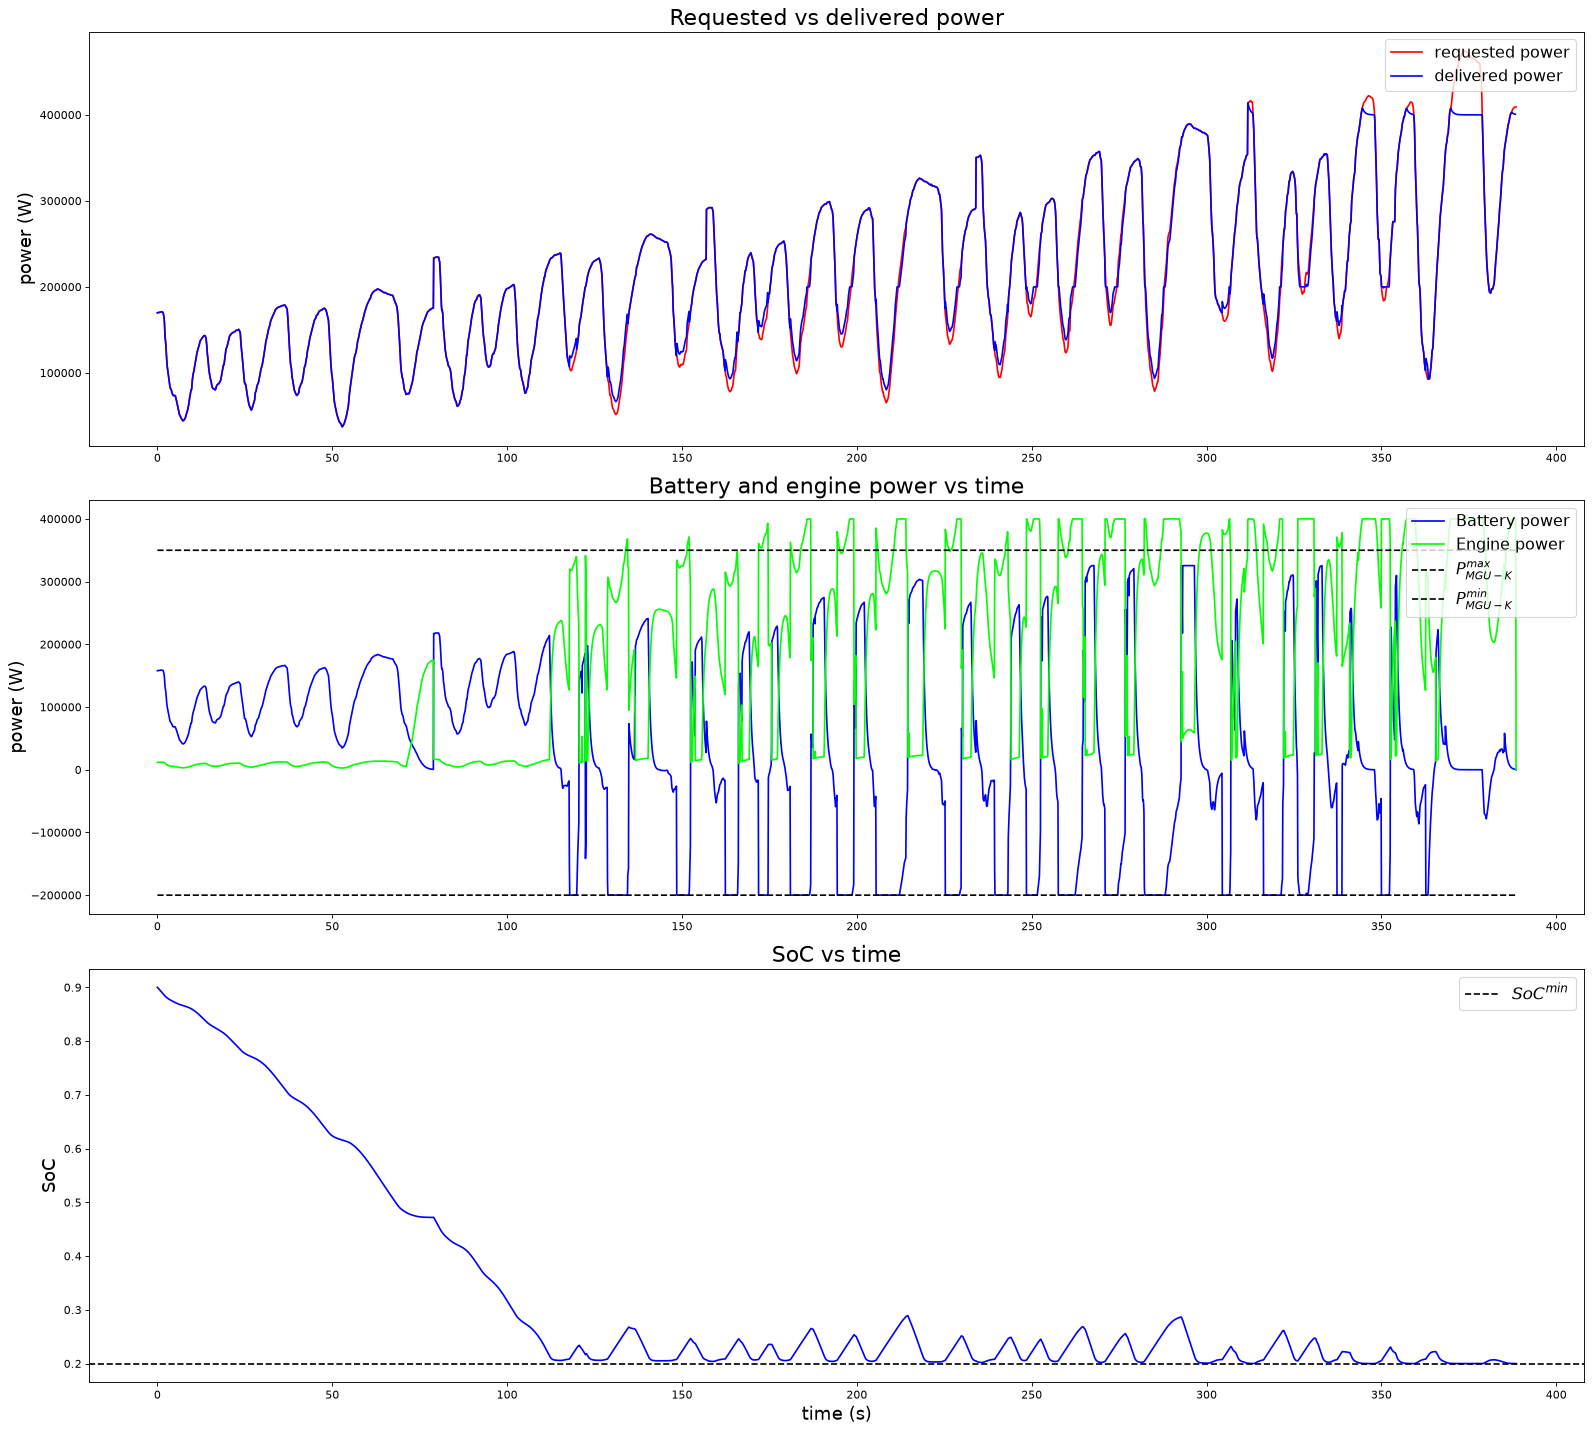

In [49]:
## Tracking and shortfall analysis

fig, axs = plt.subplots(3, 1, figsize=(20, 18), dpi=80, facecolor='w', edgecolor='k')

axs[0].plot(t, Pgb, 'red', label='requested power')
axs[0].plot(t[0:-2], P_mech_MGU_K_real90[0:-2] + P_eng_sim90[0:-2], 'blue', label='delivered power')
axs[0].set_ylabel('power (W)', fontsize=16)
axs[0].set_title('Requested vs delivered power', fontsize=20)
axs[0].legend(loc=1, fontsize=14)

axs[1].plot(t, P_mech_MGU_K_real90, 'blue', label='Battery power')
axs[1].plot(t, P_eng_sim90, 'lime', label='Engine power')
axs[1].plot(t, P_MGU_K_max*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{max}$')
axs[1].plot(t, P_MGU_K_min*np.ones(t.shape), 'k--', label=r'$P_{MGU-K}^{min}$')
axs[1].set_ylabel('power (W)', fontsize=16)
axs[1].set_title('Battery and engine power vs time', fontsize=20)
axs[1].legend(loc=1, fontsize=14)

axs[2].plot(t, SoC_sim90, 'blue')
axs[2].axhline(SoC_min, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[2].set_xlabel('time (s)', fontsize=16)
axs[2].set_ylabel('SoC', fontsize=16)
axs[2].set_title('SoC vs time', fontsize=20)
axs[2].legend(loc=1, fontsize=15)

plt.tight_layout()
plt.show()

The top plot compares the power requested by the driving profile with the power actually delivered by the DP optimal strategy. Tracking is nearly exact for most of the race, but a visible gap opens in the last laps, where delivered power falls below the request during traction peaks.

The middle plot shows why: in those laps the delivered power ceiling is essentially $P_{ICE}^{max}$, the engine alone. The MGU-K contribution is missing not because the battery hits its rated power limit, but because SoC has reached $SoC^{min}$, so there is no usable charge left to draw from.

The bottom plot confirms this directly. SoC drops from 0.9 to $SoC^{min}$ within the first two laps, then stays there for the rest of the race, oscillating in a sawtooth pattern between small discharge and regenerative recharge cycles. The shortfall period lines up exactly with the stretch where SoC sits at its floor. This is a direct consequence of the cost function used in the backward pass, which penalizes only fuel consumption and gives no incentive to preserve any reserve for the closing laps.

## 5. Lap energy balance

To understand how the deploy budget is used across the race, I look at $E_{ES2K}$ (energy deployed within the current lap, reset to zero at every lap boundary) and $E_{K2ES}$ (cumulative regenerated energy) over time. This separates how much of the 9 MJ per lap budget is actually used from how much the battery recovers through braking, which is what the SoC trace alone cannot show directly.

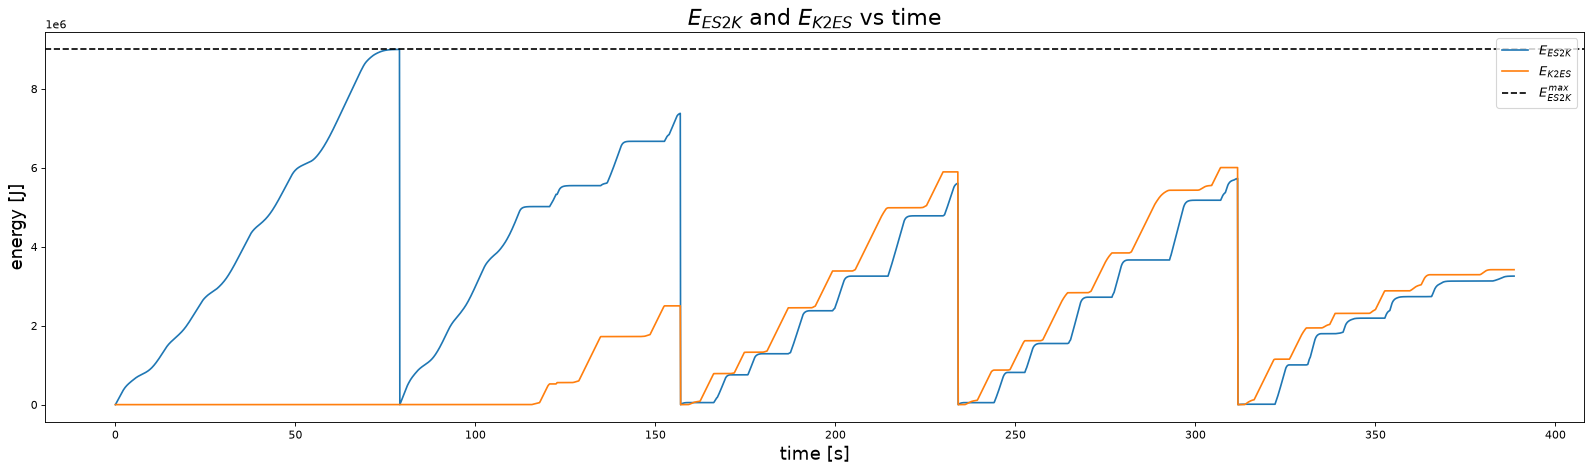

In [50]:
fig, ax = plt.subplots(figsize=(20, 6), dpi=80)
ax.plot(t, E_ES2K_sim90, label=r'$E_{ES2K}$')
ax.plot(t, E_K2ES_sim, label=r'$E_{K2ES}$')
ax.axhline(E_ES2K_max, linestyle='--', color='k', label=r'$E_{ES2K}^{max}$')
ax.set_xlabel('time [s]', fontsize=16)
ax.set_ylabel('energy [J]', fontsize=16)
ax.set_title(r'$E_{ES2K}$ and $E_{K2ES}$ vs time', fontsize=20)
ax.legend(loc=1, fontsize=12)
plt.tight_layout()
plt.show()

$E_{ES2K}$ reaches the 9 MJ cap only in the first lap. From the second lap onward the peak deployed energy decreases monotonically, lap after lap, as less usable charge is available. From the third lap onward the picture flips: the area under $E_{K2ES}$ exceeds the area under $E_{ES2K}$, meaning the battery recovers more energy through braking than it deploys. This is consistent with SoC sitting at its floor: once there is little charge left to draw from, deployment is naturally capped by the state constraint, while regeneration from braking is never capped in the same way, so recharge starts to dominate by construction rather than by any deliberate energy management choice.

The picture that emerges is a strategy that is not just front loaded, it also changes shape from lap to lap: lap 1 looks nothing like lap 3, which looks nothing like lap 5. This lack of repeatability, not just the shortfall itself, is the second motivation for introducing a constraint at the end of each lap.

## 6. Soft constraint on end of lap SoC

The baseline strategy is optimal for fuel, but it is not repeatable: the shape of deployment and recovery changes from lap to lap, since SoC is driven down early and never recovers to a comparable level. From the third lap onward the strategy also changes nature, recovery starts to dominate deployment simply because there is little charge left to draw from, not by any deliberate choice.

To obtain a strategy that behaves consistently lap after lap, a soft constraint is added on SoC at the end of every lap. Rather than an equality target, an asymmetric hinge penalty is used, so that SoC values above the target are never penalized and only values below it are pushed upward. This is deliberate: an equality constraint would penalize the DP even when it ends a lap with more charge than needed, which is never a feasibility problem, only a fuel inefficiency the cost function already accounts for on its own. The one sided penalty only intervenes where the baseline actually failed to be repeatable, without discarding fuel savings that come at no cost to consistency.

The penalty is added directly to the value function at every lap boundary, right after the standard backward recursion has produced it, before the value is used by the previous time step.

## 7. Three case comparison

Three variants are compared to quantify the trade off between fuel consumption and lap to lap repeatability.

Case 1, baseline: no constraint, the value function boundary condition is only $V(SoC, E_{ES2K}, N) = 0$ at the end of the race.

Case 2, fixed floor: a constant target $SoC_{target} = 0.7$ is enforced at the end of every lap.

Case 3, lap dependent floor: the target is left low or absent in the early laps, where the baseline shows no shortfall, and raised only in the later laps, where the shortfall was actually observed. This targets the fix at the laps where it is needed instead of paying the fuel cost of a floor everywhere.

In [ ]:
SoC_target_per_lap = np.array([0.2, 0.2, 0.5, 0.6, 0.7])

V_baseline, u_star_baseline = backward_step()
V_fixed,    u_star_fixed    = backward_step(SoC_target=0.7, beta=1e6)
V_var,      u_star_var      = backward_step(SoC_target=SoC_target_per_lap, beta=1e6)

results = {}
for name, u in [('baseline', u_star_baseline), ('fixed', u_star_fixed), ('variable', u_star_var)]:
    P_eng, P_mgu, E_ES2K, E_K2ES, SoC, J = foward_step(u, SoC_0=0.9, E_ES2K_0=0.0)
    results[name] = dict(P_eng=P_eng, P_mgu=P_mgu, E_ES2K=E_ES2K, E_K2ES=E_K2ES, SoC=SoC, J=J)

fig, axs = plt.subplots(3, 1, figsize=(20, 15), dpi=80)
colors = {'baseline': 'red', 'fixed': 'green', 'variable': 'blue'}

for name in results:
    axs[0].plot(t, results[name]['SoC'], color=colors[name], label=name)
axs[0].axhline(SoC_min, color='k', linestyle='--')
axs[0].set_ylabel('SoC')
axs[0].set_title('SoC vs time, three cases')
axs[0].legend(loc=1)

for name in results:
    delivered = results[name]['P_eng'] + results[name]['P_mgu']
    shortfall = np.maximum(0, Pgb - delivered)
    axs[1].plot(t[0:-2], shortfall[0:-2], color=colors[name], label=name)
axs[1].set_ylabel('shortfall (W)')
axs[1].set_title('Power shortfall vs time, three cases')
axs[1].legend(loc=1)

for name in results:
    axs[2].plot(t, np.cumsum(results[name]['J']), color=colors[name], label=name)
axs[2].set_xlabel('time (s)')
axs[2].set_ylabel('fuel (kg)')
axs[2].set_title('Cumulative fuel consumption, three cases')
axs[2].legend(loc=1)

plt.tight_layout()
plt.show()

for name in results:
    total_fuel = np.sum(results[name]['J'])
    delivered = results[name]['P_eng'] + results[name]['P_mgu']
    total_shortfall_energy = np.sum(np.maximum(0, Pgb - delivered))*dt
    print(f"{name}: fuel = {total_fuel:.4f} kg, shortfall energy = {total_shortfall_energy/1e6:.3f} MJ")

The SoC plot shows how much reserve each case preserves through the race. The shortfall plot isolates exactly where and how much delivered power falls short of the request, which is the metric that matters for lap time. The cumulative fuel plot and the printed totals quantify what each case costs in exchange for reducing that shortfall, giving a direct trade off between performance and fuel economy across the three strategies.